In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re
import cosinorage as csa
import numpy as np

In [8]:
def recompute_wear_periods(
    input_dir="minute_level",
    output_file="wear_periods_recomputed.csv",
    threshold=0.005,
    min_duration_minutes_nonwear=30,
    min_duration_minutes_wear=30
):
    def detect_non_wear_mask_periods(df, threshold=0.01, min_duration_minutes_nonwear=30):
        """Detect non-wear periods based on low rolling std of norm(x, y, z) signal."""
        # Compute the norm over x, y, z axes
        norm = (df['x']**2 + df['y']**2 + df['z']**2)**0.5
        norm = pd.Series(norm, index=df.index)
        rolling_std = norm.rolling('15min').std()
        mask = rolling_std < threshold
        periods = []
        start = None
        for t, is_non in mask.items():
            if is_non and start is None:
                start = t
            elif not is_non and start is not None:
                if (t - start).total_seconds() >= min_duration_minutes_nonwear*60:
                    periods.append((start, t))
                start = None
        # Handle case where non-wear goes to the end
        if start is not None and (df.index[-1] - start).total_seconds() >= min_duration_minutes_nonwear*60:
            periods.append((start, df.index[-1]))
        return periods

    def merge_intervals(intervals):
        """Merge overlapping intervals."""
        if not intervals:
            return []
        intervals = sorted(intervals)
        merged = [list(intervals[0])]
        for s, e in intervals[1:]:
            if s <= merged[-1][1]:
                merged[-1][1] = max(merged[-1][1], e)
            else:
                merged.append([s, e])
        return [(s, e) for s, e in merged]

    def detect_wear_periods(df, threshold=0.1, min_duration_minutes_nonwear=15, min_duration_minutes_wear=30):
        """Wear = complement of non-wear within data window, with minimum wear period duration enforced."""
        nonwears = detect_non_wear_mask_periods(df, threshold, min_duration_minutes_nonwear)
        nonwears = merge_intervals(nonwears)
        if not nonwears:
            return [(df.index.min(), df.index.max())]

        wear_periods = []
        cur_start = df.index.min()
        for s, e in nonwears:
            if s > cur_start:
                wear_periods.append((cur_start, s))
            cur_start = e
        if cur_start < df.index.max():
            wear_periods.append((cur_start, df.index.max()))

        # Enforce minimum wear period duration
        min_wear_seconds = min_duration_minutes_wear * 60
        filtered_wear_periods = [
            (s, e) for s, e in merge_intervals(wear_periods)
            if (e - s).total_seconds() >= min_wear_seconds
        ]
        return filtered_wear_periods

    # === Build new wear_periods dataframe ===
    rows = []
    csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
    for file_path in csv_files:
        pig_id = os.path.basename(file_path).split(".")[0]
        pig_id = pig_id.replace("_", "-")
        if pig_id.startswith("CO") and not pig_id.startswith("CO-"):
            pig_id = pig_id[:2] + "-" + pig_id[2:]  # normalize CO001 -> CO-001

        df = pd.read_csv(file_path, parse_dates=['timestamp'])
        df = df.set_index('timestamp')

        wear_ints = detect_wear_periods(
            df,
            threshold=threshold,
            min_duration_minutes_nonwear=min_duration_minutes_nonwear,
            min_duration_minutes_wear=min_duration_minutes_wear
        )

        row = {"pig_id": pig_id}
        for i, (s, e) in enumerate(wear_ints, start=1):
            row[f"wear_start_{i}"] = s
            row[f"wear_end_{i}"] = e
        rows.append(row)

    new_wear_df = pd.DataFrame(rows)
    new_wear_df.to_csv(output_file, index=False)
    return new_wear_df

def plot_pig_wear_timeseries(
    wear_csv, 
    input_dir, 
    axis='x',
    limit=None
):
    """
    For each pig_id in the wear CSV, find the corresponding CSV file in input_dir and plot the x-axis timeseries.
    Wear periods are highlighted in green, and valid wear hours are displayed in the title.
    
    Parameters:
        wear_csv (str): Path to CSV file containing 'pig_id' and wear_start_/wear_end_ columns
        input_dir (str): Directory containing timestamped x-axis data CSVs
        axis (str): Which axis to plot ('x', 'y', or 'z')
        limit (int or None): Maximum number of pigs to plot
    """
    import pandas as pd
    import os
    import glob
    import re
    import matplotlib.pyplot as plt

    wear_df = pd.read_csv(wear_csv)
    wear_df.columns = [c.strip() for c in wear_df.columns]
    wear_df = wear_df.map(lambda x: x.strip() if isinstance(x, str) else x)
    csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))

    for idx, row in wear_df.iterrows():
        if limit is not None and idx >= limit:
            break

        pig_id = row['pig_id']
        # Accept both CO-001.csv and CO_001.csv, case-insensitive
        pig_id_pattern = pig_id.replace("-", "[-_]?")
        pattern = re.compile(rf"{pig_id_pattern}\.csv$", re.IGNORECASE)
        matching_files = [f for f in csv_files if pattern.search(os.path.basename(f))]
        if not matching_files:
            print(f"No file found for pig_id {pig_id}")
            continue
        csv_file = matching_files[0]

        df = pd.read_csv(csv_file)
        ts = pd.to_datetime(df['timestamp'])
        file_label = os.path.basename(csv_file)

        plt.figure(figsize=(12, 2))
        plt.plot(ts, df[f'{axis}'], label=f"{file_label} {axis}")
        plt.axvline(ts.min(), color='g', linestyle='--', label='Min timestamp')
        plt.axvline(ts.max(), color='r', linestyle='--', label='Max timestamp')

        # Plot wear periods as green bands and collect valid wear intervals
        wear_intervals = []
        n_max_wear_periods = (wear_df.shape[1] - 1) // 2

        for i in range(1, n_max_wear_periods + 1):
            start_col = f'wear_start_{i}'
            end_col = f'wear_end_{i}'
            start = row[start_col] if pd.notna(row[start_col]) else ''
            end = row[end_col] if pd.notna(row[end_col]) else ''
            if start and end:
                start_dt = pd.to_datetime(start)
                end_dt = pd.to_datetime(end)
                # Only consider wear periods before the signal ends
                end_dt = min(end_dt, ts.max())
                if start_dt > ts.max():
                    continue
                plt.axvspan(start_dt, end_dt, color='green', alpha=0.2)
                wear_intervals.append((start_dt, end_dt))

        # Calculate valid wear hours
        wear_hours = sum((end - start).total_seconds() / 3600.0 for start, end in wear_intervals)

        # Calculate total hours covered by the timeseries
        total_hours = ((ts.max().floor('h') - ts.min().floor('h')).total_seconds() / 3600.0) if not ts.empty else 0.0

        plt.xlabel('Timestamp')
        plt.ylabel(f'{axis} axis data')
        plt.title(f'{axis} axis data for {file_label} (valid wear hours: {round(wear_hours)}/{round(total_hours)})')
        plt.show()

def save_modified_timeseries(
    wear_csv, 
    input_dir, 
    output_dir="minute_level_modified", 
    max_wear_periods=1000,
    day_start="07:00",
    day_end="19:00"
):
    """
    For each pig_id in wear_df, locate the matching timeseries CSV,
    truncate at last wear period or file end, fill non-wear with wear mean during day
    and 0 during night (cutoff times settable by parameter),
    save modified data.

    Parameters
    ----------
    wear_df : pd.DataFrame
        DataFrame with pig_id and wear_start_/wear_end_ columns
    csv_files : list
        List of candidate CSV files containing timestamped x,y,z data
    output_dir : str
        Directory where modified CSVs will be saved
    max_wear_periods : int
        Maximum number of wear_start_/wear_end_ columns to check
    day_start : str
        Start of day period in "HH:MM" (inclusive)
    day_end : str
        End of day period in "HH:MM" (exclusive)
    """
    import datetime

    wear_df = pd.read_csv(wear_csv)
    wear_df.columns = [c.strip() for c in wear_df.columns]
    wear_df = wear_df.map(lambda x: x.strip() if isinstance(x, str) else x)
    csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))

    os.makedirs(output_dir, exist_ok=True)

    # Parse day_start and day_end as time objects
    day_start_time = datetime.datetime.strptime(day_start, "%H:%M").time()
    day_end_time = datetime.datetime.strptime(day_end, "%H:%M").time()

    for idx, row in wear_df.iterrows():
        pig_id = row['pig_id']
        # Accept both CO-001.csv and CO_001.csv, case-insensitive
        pig_id_pattern = pig_id.replace("-", "[-_]?")
        pattern = re.compile(rf"{pig_id_pattern}\.csv$", re.IGNORECASE)
        matching_files = [f for f in csv_files if pattern.search(os.path.basename(f))]
        if not matching_files:
            print(f"No file found for pig_id {pig_id}")
            continue
        csv_file = matching_files[0]

        df = pd.read_csv(csv_file)
        ts = pd.to_datetime(df['timestamp'])
        file_label = os.path.basename(csv_file)

        # Build wear mask
        wear_mask = pd.Series(False, index=df.index)
        wear_periods = []
        last_wear_end = None
        
        max_wear_periods_eff = wear_df.shape[1] // 2 if max_wear_periods is None else max_wear_periods

        for i in range(1, max_wear_periods_eff + 1):
            start_col, end_col = f'wear_start_{i}', f'wear_end_{i}'
            start = row[start_col] if start_col in row and pd.notna(row[start_col]) else None
            end = row[end_col] if end_col in row and pd.notna(row[end_col]) else None
            if start is not None and end is not None:
                start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
                mask = (ts >= start_dt) & (ts <= end_dt)
                wear_mask = wear_mask | mask
                wear_periods.append((start_dt, end_dt))
                if last_wear_end is None or end_dt > last_wear_end:
                    last_wear_end = end_dt

        # Truncate at cutoff
        cutoff = min(last_wear_end, ts.max()) if last_wear_end is not None else ts.max()
        valid_mask = ts <= cutoff
        ts_valid = ts[valid_mask]
        df_valid = df.loc[valid_mask].copy()
        wear_mask_valid = wear_mask[valid_mask]

        # Compute average during wear
        wear_mean = df_valid.loc[wear_mask_valid, 'x'].mean() if wear_mask_valid.any() else df_valid['x'].mean()

        # Determine day/night for each timestamp
        # Day: day_start <= time < day_end, else night
        times = ts_valid.dt.time
        is_day = times.apply(
            lambda t: (day_start_time <= t < day_end_time)
            if day_start_time < day_end_time
            else (t >= day_start_time or t < day_end_time)
        )

        # Fill non-wear: day with mean, night with 0
        df_filled = df_valid.copy()
        non_wear_mask = ~wear_mask_valid

        # Set up boolean masks for non-wear during day and night
        non_wear_day_mask = non_wear_mask & is_day.values
        non_wear_night_mask = non_wear_mask & (~is_day.values)

        df_filled.loc[non_wear_day_mask, 'x'] = wear_mean
        df_filled.loc[non_wear_night_mask, 'x'] = 0.0

        # Save to CSV
        cols_to_save = [c for c in ['timestamp', 'x', 'y', 'z'] if c in df_filled.columns]
        output_path = os.path.join(output_dir, file_label)
        df_filled[cols_to_save].to_csv(output_path, index=False)

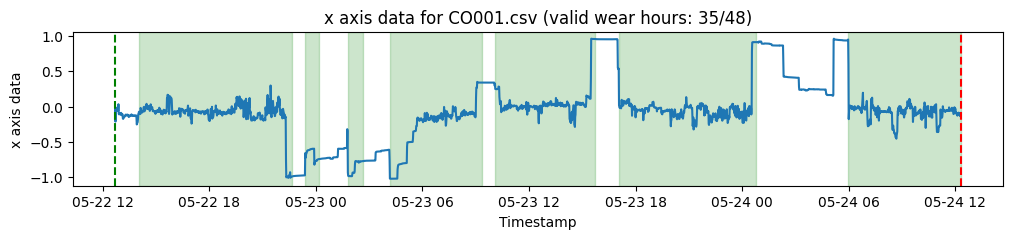

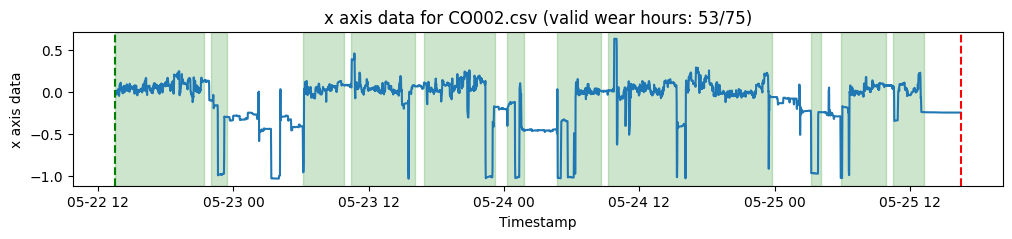

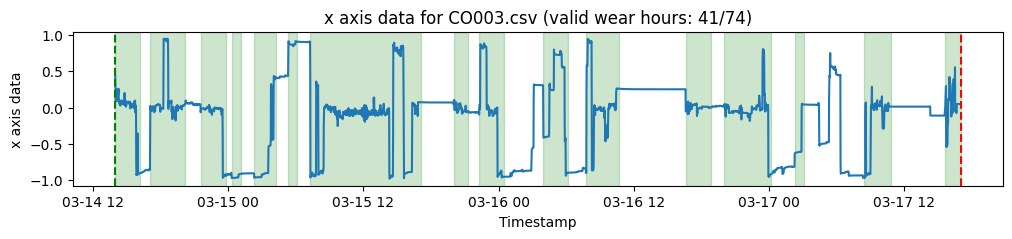

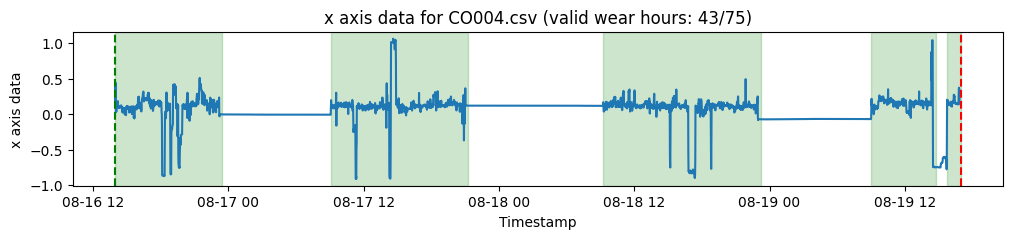

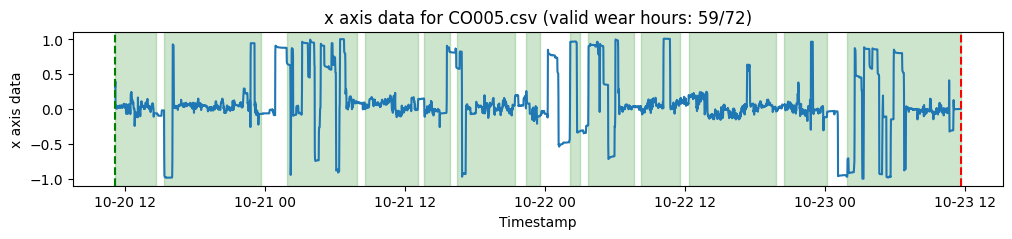

In [9]:
recompute_wear_periods()
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=5, axis='x')

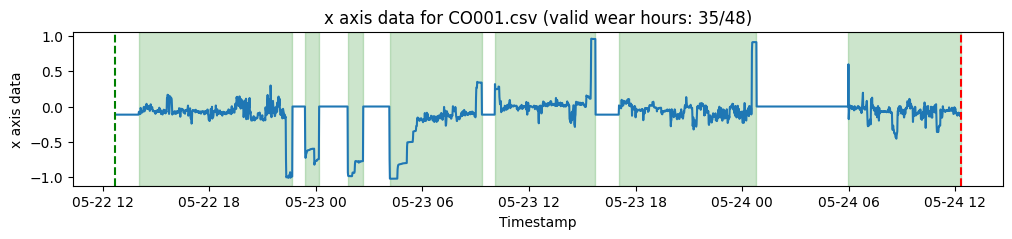

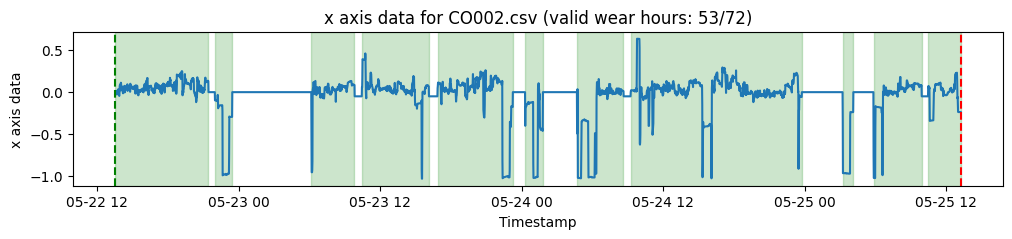

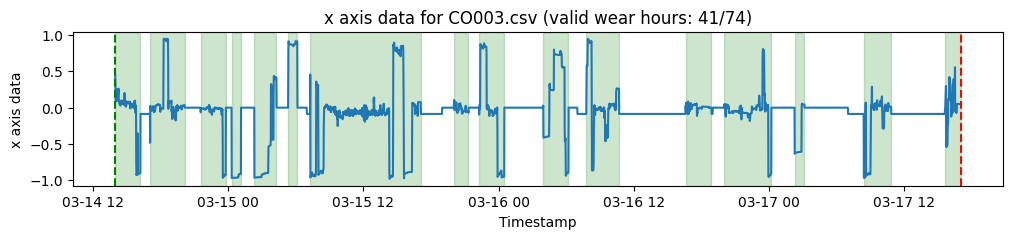

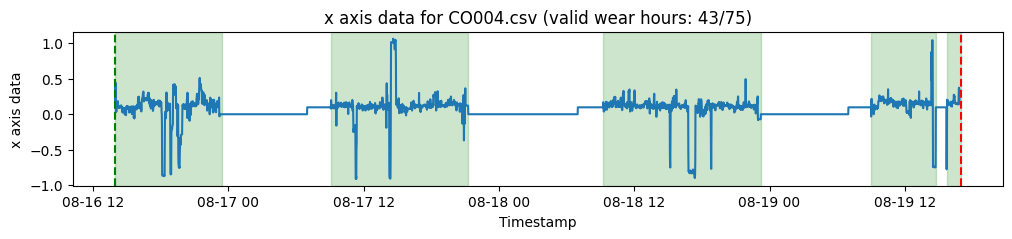

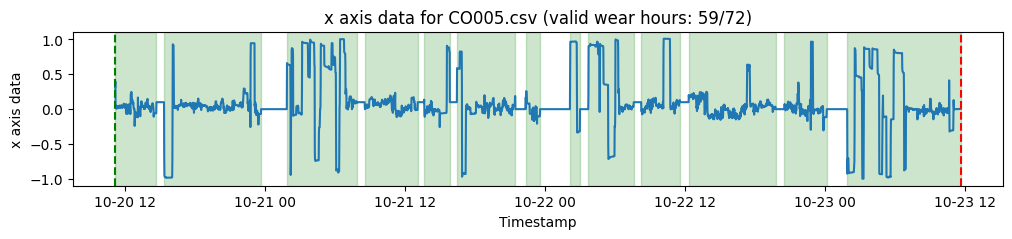

In [10]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified")
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=5, axis='x')

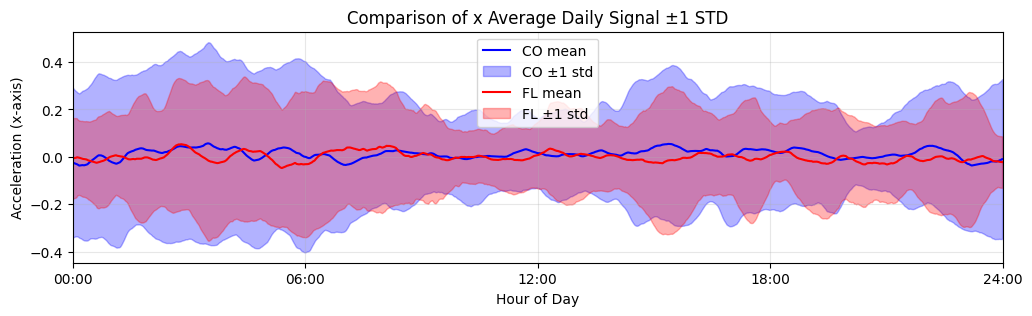

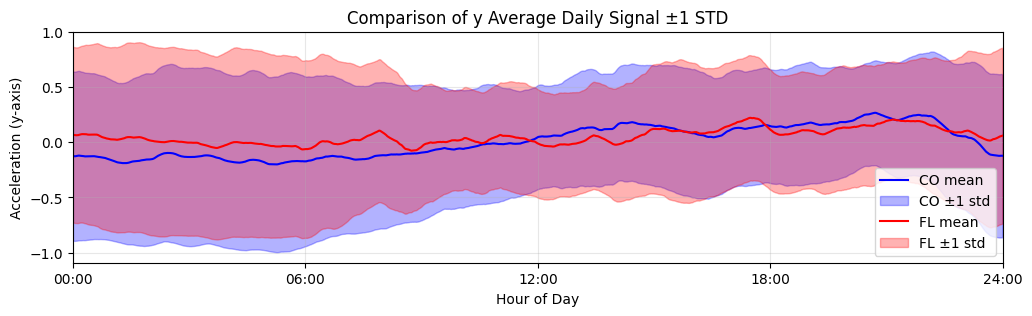

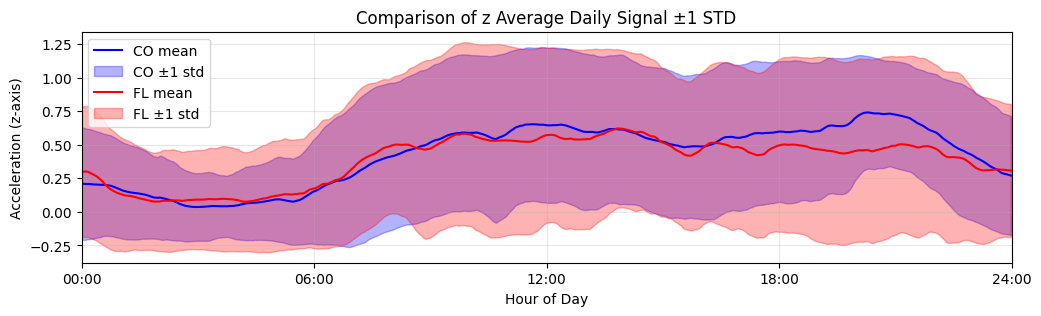

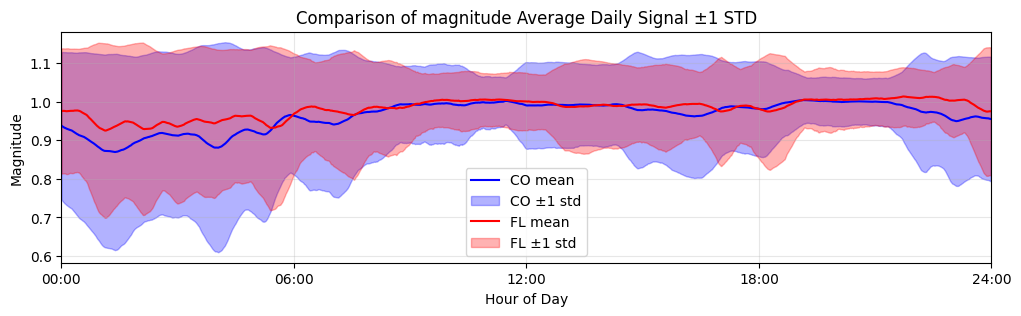

In [25]:
# ----------------------
# 1. Load files for each cohort
# ----------------------
co_files = glob.glob("minute_level_modified/CO*.csv")
fl_files = glob.glob("minute_level_modified/FL*.csv")

def load_and_concat(file_list):
    all_data = []
    for f in file_list:
        df = pd.read_csv(f, parse_dates=['timestamp'])
        all_data.append(df)
    data = pd.concat(all_data)
    # fractional hour
    data['hour'] = data['timestamp'].dt.hour + data['timestamp'].dt.minute/60 + data['timestamp'].dt.second/3600
    # magnitude
    data['magnitude'] = np.sqrt(data['x']**2 + data['y']**2 + data['z']**2)
    return data

co_data = load_and_concat(co_files)
fl_data = load_and_concat(fl_files)

# ----------------------
# 2. Group by hour for a given column
# ----------------------
def group_by_hour(df, column, window=30):
    """
    df: dataframe
    column: column to aggregate
    window: rolling window size in number of points (e.g., hours)
    """
    grouped = df.groupby('hour')[[column]].agg(['mean','std']).reset_index()
    
    # Apply rolling smoothing
    grouped[(column,'mean')] = grouped[(column,'mean')].rolling(window=window, center=True, min_periods=1).mean()
    grouped[(column,'std')] = grouped[(column,'std')].rolling(window=window, center=True, min_periods=1).mean()
    
    return grouped

# ----------------------
# 3. Plot function
# ----------------------
def plot_comparison(column, ylabel=None):
    co_grouped = group_by_hour(co_data, column)
    fl_grouped = group_by_hour(fl_data, column)
    
    plt.figure(figsize=(12,3))
    
    # CO
    plt.plot(co_grouped['hour'], co_grouped[(column,'mean')], color='blue', label='CO mean')
    plt.fill_between(co_grouped['hour'],
                     co_grouped[(column,'mean')] - co_grouped[(column,'std')],
                     co_grouped[(column,'mean')] + co_grouped[(column,'std')],
                     color='blue', alpha=0.3, label='CO ±1 std')
    
    # FL
    plt.plot(fl_grouped['hour'], fl_grouped[(column,'mean')], color='red', label='FL mean')
    plt.fill_between(fl_grouped['hour'],
                     fl_grouped[(column,'mean')] - fl_grouped[(column,'std')],
                     fl_grouped[(column,'mean')] + fl_grouped[(column,'std')],
                     color='red', alpha=0.3, label='FL ±1 std')
    
    plt.xlabel('Hour of Day')
    plt.ylabel(ylabel if ylabel else column)
    plt.title(f'Comparison of {column} Average Daily Signal ±1 STD')
    plt.legend()
    plt.xlim(0, 24)
    plt.grid(alpha=0.3)

    # ----------------------
    # Show ticks every 6 hours
    # ----------------------
    ticks = np.arange(0,25,6)  # 0, 6, 12, 18, 24
    tick_labels = [f'{int(t):02d}:00' for t in ticks]
    plt.xticks(ticks, tick_labels)

    plt.show()

# ----------------------
# 4. Plot x, y, z, magnitude
# ----------------------
plot_comparison('x', 'Acceleration (x-axis)')
plot_comparison('y', 'Acceleration (y-axis)')
plot_comparison('z', 'Acceleration (z-axis)')
plot_comparison('magnitude', 'Magnitude')

In [ ]:
modified_dir = "minute_level_modified"
header_dir = "headers"
data_handlers = []
cosinor_age_inputs = []

preprocess_args = {}  # Define or update this as needed

for fname in os.listdir(modified_dir):
    try:
        file_path = os.path.join(modified_dir, fname)
        header_path = os.path.join(header_dir, fname.replace('.csv', '.hea'))

        if os.path.isfile(file_path) and os.path.isfile(header_path):
            handler = csa.datahandlers.GenericDataHandler(
                file_path=file_path,
                data_format='csv',
                data_type='accelerometer-g',
                time_format='datetime',
                time_column='timestamp',
                time_zone="UTC",
                data_columns=['x', 'y', 'z'],
                preprocess_args=preprocess_args,
                verbose=False
            )
            data_handlers.append(handler)

            with open(header_path, "r") as f:
                    for line in f:
                        line = line.strip()
                        if line.startswith("#Age:"):
                            try:
                                age = float(line.split(":", 1)[1])
                            except ValueError:
                                pass
                        elif line.startswith("#Sex:"):
                            gender = line.split(":", 1)[1].strip().upper()
                            if gender == "M":
                                gender = "male"
                            elif gender == "F":
                                gender = "female"
                            else:
                                gender = "unknown"
            cosinor_age_inputs.append(
                {"age": age, "gender": gender, "gt_cosinor_age": None}
            )

    except Exception as e:
        print(f"Error processing {fname}: {e}")

Error processing FL009.csv: Less than 1 day found
Error processing CO024.csv: Less than 1 day found


In [ ]:
features_args = {}

bulk_features = csa.features.BulkWearableFeatures(
    handlers=data_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=cosinor_age_inputs
    )

bulk_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,52,24.104517,18.040290,0.271353,65.463433,21.048133,7.723928,35.658616,27.934688,0.271353,0.504245
1,cosinor_amplitude,52,16.207756,14.531557,0.481818,79.163323,12.914420,4.636052,24.697239,20.061187,0.481818,1.851031
2,cosinor_acrophase,52,-3.236231,1.781462,-6.264906,-0.178364,-3.867809,-4.475224,-1.326704,3.148520,-6.264906,0.276780
3,cosinor_acrophase_time,52,741.689558,408.280919,40.877990,1435.810800,886.436412,304.058178,1025.645697,721.587519,40.877990,-0.276780
4,nonparam_IS,52,0.655560,0.256970,0.209507,1.000000,0.694797,0.412915,0.872202,0.459287,1.000000,-0.135265
5,nonparam_IV,52,0.710399,0.408718,0.143992,1.764827,0.652394,0.381250,1.000434,0.619184,0.143992,0.717523
6,nonparam_M10,52,37.242560,25.779769,0.651246,89.119899,34.274340,16.923783,54.510714,37.586931,0.651246,0.383273
7,nonparam_L5,52,4.649258,7.685704,0.000000,39.375710,0.208947,0.000000,7.336575,7.336575,0.000000,2.409428
8,nonparam_RA,52,0.853216,0.195775,0.214535,1.000000,0.994970,0.727100,1.000000,0.272900,1.000000,-1.255684
9,physical_activity_sedentary,52,710.307692,367.368843,116.500000,1382.000000,635.750000,397.750000,994.875000,597.125000,116.500000,0.320671


In [ ]:
bulk_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.755822,-0.059395,0.059395,0.293739,-0.219442,0.974496,0.662878,-0.487669,-0.776878,...,-0.042759,0.779425,-0.754673,0.344632,-0.754673,-0.226205,0.043594,0.364622,-0.623676,-0.837398
cosinor_amplitude,0.755822,1.000000,0.074014,-0.074014,0.417327,-0.507464,0.857374,0.138708,0.027215,-0.466020,...,0.122913,0.465926,-0.451369,0.107204,-0.451369,-0.162190,0.086120,0.192952,-0.647740,-0.775410
cosinor_acrophase,-0.059395,0.074014,1.000000,-1.000000,0.083385,-0.319388,-0.009153,-0.094856,-0.049860,-0.051707,...,0.133122,0.049831,0.123371,0.156389,0.123372,0.399430,-0.034922,0.332542,-0.063417,-0.157032
cosinor_acrophase_time,0.059395,-0.074014,-1.000000,1.000000,-0.083385,0.319388,0.009153,0.094856,0.049860,0.051707,...,-0.133122,-0.049831,-0.123371,-0.156389,-0.123372,-0.399430,0.034922,-0.332542,0.063417,0.157032
nonparam_IS,0.293739,0.417327,0.083385,-0.083385,1.000000,0.006390,0.295563,0.057691,0.089681,-0.224074,...,0.180961,0.222701,-0.177145,0.154537,-0.177143,-0.286621,-0.171909,0.576230,-0.187273,-0.240682
nonparam_IV,-0.219442,-0.507464,-0.319388,0.319388,0.006390,1.000000,-0.329202,0.183156,-0.106097,0.356352,...,-0.309506,-0.353644,0.312741,-0.111098,0.312740,-0.121816,-0.204977,-0.016367,0.416698,0.449148
nonparam_M10,0.974496,0.857374,-0.009153,0.009153,0.295563,-0.329202,1.000000,0.537561,-0.356767,-0.727506,...,-0.003416,0.729478,-0.700017,0.318650,-0.700017,-0.197189,0.070308,0.300590,-0.682851,-0.876458
nonparam_L5,0.662878,0.138708,-0.094856,0.094856,0.057691,0.183156,0.537561,1.000000,-0.875385,-0.646141,...,-0.106778,0.648962,-0.571500,0.422609,-0.571499,-0.101696,-0.115801,0.382789,-0.288135,-0.461139
nonparam_RA,-0.487669,0.027215,-0.049860,0.049860,0.089681,-0.106097,-0.356767,-0.875385,1.000000,0.714033,...,-0.049360,-0.715081,0.616700,-0.499047,0.616700,-0.115115,0.065898,-0.406541,0.161840,0.319449
physical_activity_sedentary,-0.776878,-0.466020,-0.051707,0.051707,-0.224074,0.356352,-0.727506,-0.646141,0.714033,1.000000,...,-0.221611,-0.999937,0.923189,-0.538194,0.923188,0.060503,-0.080739,-0.479665,0.488391,0.697891
